
# Telco Customer Churn — EDA → Features → Models → Evaluation → Interpretation → Monitoring

**Dataset**: `WA_Fn-UseC_-Telco-Customer-Churn.csv`

**What this notebook does**
1. Loads data & performs EDA (class balance, distributions, grouped churn rates)
2. Cleans & engineers features (normalize flags, impute `TotalCharges`, `ServicesCount`, `TenureGroup`)
3. Trains 3 models (Logistic Regression, Random Forest, Gradient Boosting)
4. Compares metrics (Accuracy, Precision, Recall, F1, ROC AUC, PR AUC)
5. Recommends a model & explains drivers (Permutation Importance on base features)
6. Saves helpful figures to `./figures` and prints confusion matrices & curves
7. Outlines a production monitoring checklist


## 0. Setup

In [3]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
Path('figures').mkdir(exist_ok=True)

## 1. Load data & quick EDA

C:\Users\Snider\AppData\Local\Temp\ipykernel_6072\1465236850.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include=['object']).columns:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)
Churn rate: 0.2654


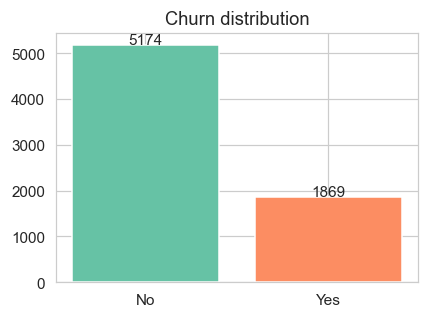

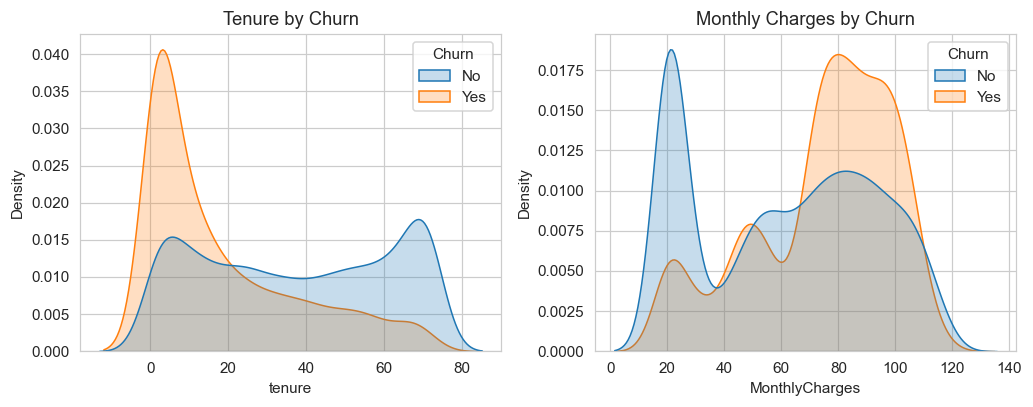

Churn rate by Contract:


Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

Churn rate by InternetService:


InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

Churn rate by PaymentMethod:


PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn, dtype: float64

Churn rate by SeniorCitizen:


SeniorCitizen
1    0.417
0    0.236
Name: Churn, dtype: float64

In [4]:

# Load datset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.columns = [c.strip() for c in df.columns]
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

display(df.head())
print('Shape:', df.shape)
print('Churn rate:', (df['Churn'].str.lower()=='yes').mean().round(4))

# Plot churn distribution (use matplotlib for robustness)
counts = df['Churn'].value_counts()
plt.figure(figsize=(4,3))
plt.bar(counts.index, counts.values, color=['#66c2a5','#fc8d62'])
plt.title('Churn distribution');
for i,v in enumerate(counts.values): plt.text(i, v+20, str(v), ha='center')
plt.tight_layout(); plt.show()

# Distributions vs churn
fig, axes = plt.subplots(1,2, figsize=(9.5,3.8))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Tenure by Churn')
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')
plt.tight_layout(); plt.show()

# Grouped churn rates
def churn_rate(col):
    return df.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()).sort_values(ascending=False)
for col in ['Contract','InternetService','PaymentMethod','SeniorCitizen']:
    if col in df.columns:
        print(f'Churn rate by {col}:')
        display(churn_rate(col).round(3))

## 2. Feature engineering & cleaning

In [5]:
# Normalize flags
service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
phone_cols = ['PhoneService','MultipleLines']
for c in service_cols: df[c] = df[c].replace({'No internet service':'No'})
for c in phone_cols: df[c] = df[c].replace({'No phone service':'No'})

# Engineered features
df['ServicesCount'] = (df[service_cols] == 'Yes').sum(axis=1)
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce').fillna(0).astype(int)
miss = df['TotalCharges'].isna()
df.loc[miss, 'TotalCharges'] = df.loc[miss, 'MonthlyCharges'] * df.loc[miss, 'tenure']

# Tenure buckets (optional)
bins = [0,12,24,48,72,np.inf]
labels = ['0-12','13-24','25-48','49-72','72+']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# Target
df['ChurnFlag'] = (df['Churn'].str.lower().map({'yes':1,'no':0})).astype(int)

df[['TotalCharges','ServicesCount','TenureGroup','Churn','ChurnFlag']].head()

,TotalCharges,ServicesCount,TenureGroup,Churn,ChurnFlag
0,29.85,1,0-12,No,0
1,1889.50,2,25-48,No,0
2,108.15,2,0-12,Yes,1
3,1840.75,3,25-48,No,0
4,151.65,0,0-12,Yes,1


## 3. Modeling (3 models)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = df.drop(columns=['customerID','Churn','ChurnFlag'], errors='ignore')
y = df['ChurnFlag']

num_features = [c for c in ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','ServicesCount'] if c in X.columns]
cat_features = [c for c in X.columns if X[c].dtype=='object']

pre = ColumnTransformer([
    ('num', Pipeline(steps=[('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'baseline_logreg': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42),
    'gradient_boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
trained = {}
for name, mdl in models.items():
    pipe = Pipeline([('preprocess', pre), ('model', mdl)])
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    y_prob = pipe.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob)
    }
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)


,accuracy,precision,recall,f1,roc_auc,pr_auc
gradient_boosting,0.789212,0.627907,0.505348,0.560000,0.830773,0.637874
baseline_logreg,0.733854,0.499096,0.737968,0.595469,0.824099,0.617869
random_forest,0.779986,0.608844,0.478610,0.535928,0.784771,0.566218


## 4. Confusion matrices & curves

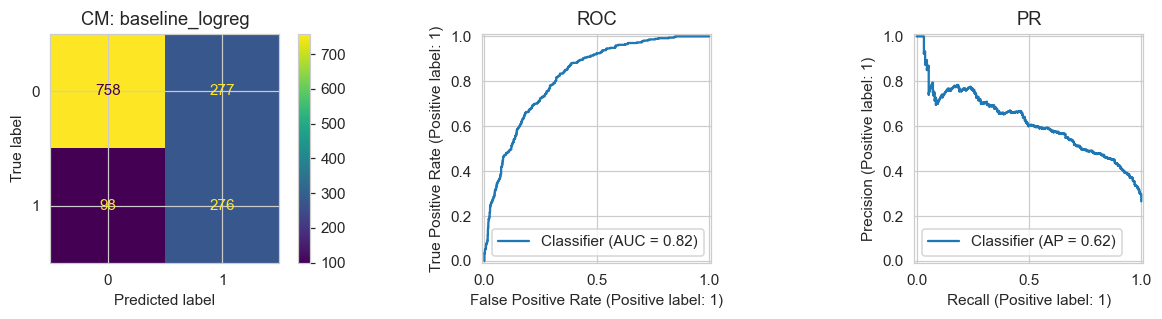

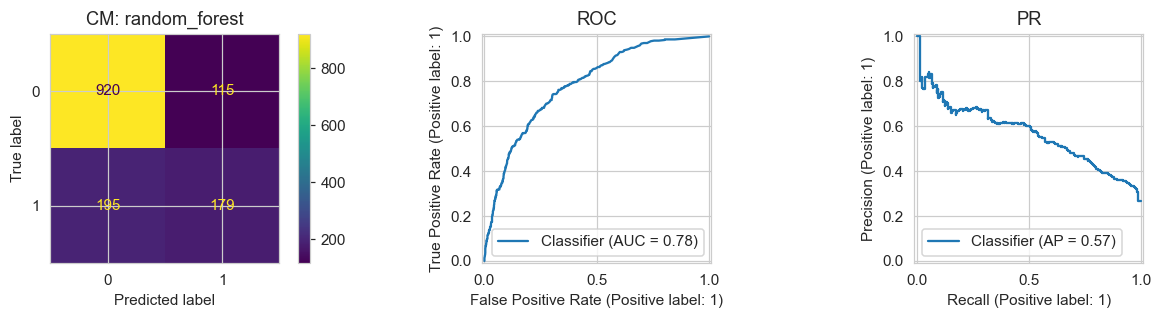

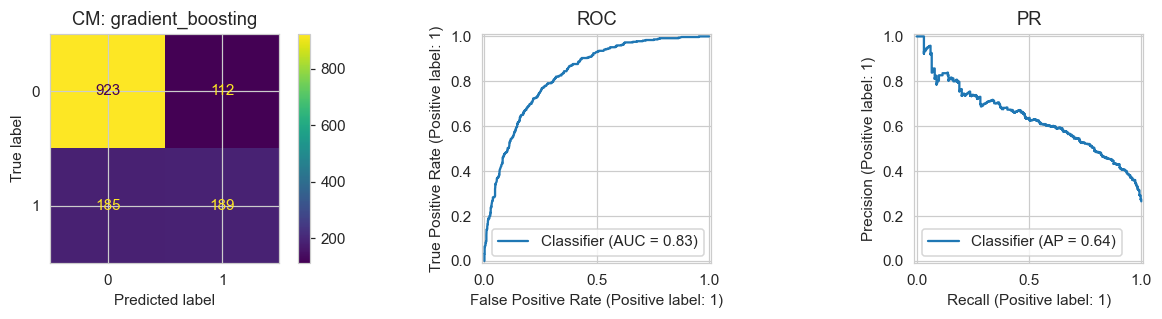

In [9]:

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
for name, pipe in trained.items():
    y_prob = pipe.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    fig, axes = plt.subplots(1,3, figsize=(12,3))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0]); axes[0].set_title(f'CM: {name}')
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1]); axes[1].set_title('ROC')
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2]); axes[2].set_title('PR')
    plt.tight_layout(); plt.show()


## 5. Interpretation — Permutation Importance (base features)

In [10]:

from sklearn.inspection import permutation_importance
import pandas as pd
# choose best by ROC AUC
best_name = max(results.items(), key=lambda kv: kv[1]['roc_auc'])[0]
best_pipe = trained[best_name]
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=5, random_state=42, scoring='roc_auc')
base_features = list(X.columns)
imp_df = pd.DataFrame({'feature': base_features,
                       'importance_mean': perm.importances_mean,
                       'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)
display(imp_df.head(15))


,feature,importance_mean,importance_std
4,tenure,0.175421,0.005060
17,MonthlyCharges,0.143717,0.016184
18,TotalCharges,0.018445,0.003224
19,ServicesCount,0.014211,0.002802
1,SeniorCitizen,0.008864,0.001192
3,Dependents,0.000000,0.000000
2,Partner,0.000000,0.000000
0,gender,0.000000,0.000000
5,PhoneService,0.000000,0.000000
9,OnlineBackup,0.000000,0.000000


## 6. Monitoring checklist (for production)


- **Performance**: Track ROC AUC & PR AUC; recall@top‑K based on outreach capacity; alert on >10% PR‑AUC drop
- **Data drift**: Monitor PSI / distribution drift for tenure, charges, contract, internet service
- **Calibration**: Reliability curves & Brier score; recalibrate via Platt/Isotonic if needed
- **Fairness**: Segment metrics if sensitive attributes exist; watch gaps
- **Ops**: Schema/feature checks, latency, error rates, retry/fallback logic
- **Retraining**: Trigger on drift, KPI degradation, or major tariff/plan changes
